### Another reminder to check the kernel you are using to make sure it can import all the imports ###

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import h5py

from scipy.interpolate import interp1d
from scipy.optimize import minimize, curve_fit
from scipy import signal
from scipy.ndimage import gaussian_filter

import astropy.constants as c
import astropy.units as u

### Load the data and models ###

In [3]:
# Load Observations
ds = xr.open_dataset("D:/Pavlicek, Emma/SDSS1411/SDSS1411_spectra.nc")
obs_wave_grid = ds.wavelength.values  # The observed wavelength grid (1D)
flux_cube = ds.flux_calibrated.values # (Time, Wavelength)
err_cube = ds.flux_calibrated_error.values 
times = ds.time.values

# Load Model Grid
model_B = "D:/Pavlicek, Emma/Flux 3D Models/flux_model_3D_B.h5"
with h5py.File(model_B, 'r') as h5:
    model_flux_cube = h5['flux'][()]       # Shape: (n_logg, n_wave, n_teff)
    model_wave_rest = h5['wavelength'][()] # THIS IS THE REST FRAME GRID
    model_gravs = h5['gravity'][()]        # e.g., 700, 750...
    model_temps = h5['temperature'][()]    # e.g., 12000, 13000...

### These methods use a predefined best-fit model (chosen log(g) and Teff) to isolate the correlation/search against the models for only the shifts (we are only looking for the RV now) ###

In [4]:
#input the best fit grid values you found via chi-squared minimization here
best_Teff_val = 13000 
best_logg_val = 7.5   

idx_t = (np.abs(model_temps - best_Teff_val)).argmin()

idx_g = (np.abs(model_gravs - (best_logg_val * 100))).argmin()

print(f"Using Model Grid Point: Teff={model_temps[idx_t]}, logg={model_gravs[idx_g]/100}")

#Extract the specific flux vector
    #Shape: (Gravity, Wavelength, Temperature)
raw_flux_nu = model_flux_cube[idx_g, :, idx_t]


#H_nu -> F_lambda transformation
wave_cm = model_wave_rest * 1e-8
H_lambda = raw_flux_nu * c.c.cgs.value / (wave_cm**2)
H_lambda_AA = H_lambda * 1e-8
model_flux_rest = 4 * np.pi * H_lambda_AA

#Create the Spline Interpolator for the REST Template
template_func = interp1d(
    model_wave_rest, 
    model_flux_rest, 
    kind='cubic', 
    bounds_error=False, 
    fill_value=np.nan
)

Using Model Grid Point: Teff=13000.0, logg=7.5


### Fitting RVs using chi-squared minimization ###

Starting RV Fit...
Fitting Sinusoid with guess: P=112.0, K=35.0

RESULT: P = 127.93 +/- 1.53 min
RESULT: K = 37.82 +/- 0.40 km/s


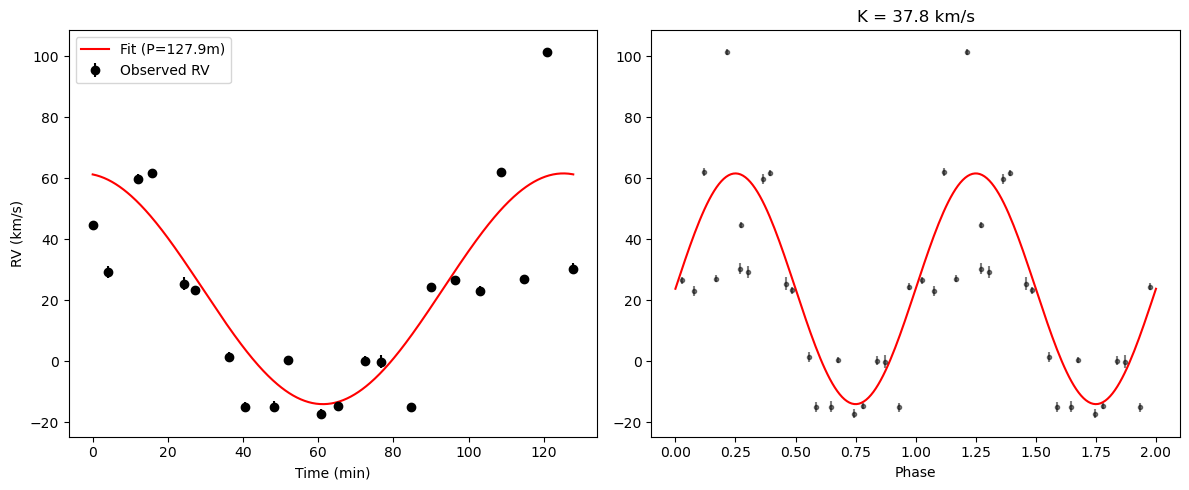

In [ ]:
c_kms = 299792.458 

def rv_chi2(v, wave_obs, flux_obs, err_obs):
    wave_shifted_to_rest = wave_obs / (1.0 + v / c_kms)
    
    model_resampled = template_func(wave_shifted_to_rest)

    mask = np.isfinite(model_resampled) & np.isfinite(flux_obs) & (err_obs > 0)
    if np.sum(mask) < 50: return 1e30
    
    y = flux_obs[mask]
    e = err_obs[mask]
    m = model_resampled[mask]

    w = 1.0 / e**2
    S = np.sum(w * m * y) / np.sum(w * m**2)
    
    residuals = y - S * m
    return np.sum((residuals / e)**2)

print("Starting RV Fit...")
rv_list = []
err_list = []

for i in range(len(times)):
    f_obs = flux_cube[i]
    e_obs = err_cube[i]
    
    res = minimize(rv_chi2, x0=[0.0], args=(obs_wave_grid, f_obs, e_obs),
                   method='L-BFGS-B', bounds=[(-1500, 1500)])
    
    best_v = res.x[0]
    
    #Estimate Error (Hessian/Curvature)
        #note that this often underestimates the error, it's a sort of quick/dirty way to do error
    step = 0.1 # km/s
    chi0 = res.fun
    chi_plus = rv_chi2(best_v + step, obs_wave_grid, f_obs, e_obs)
    chi_minus = rv_chi2(best_v - step, obs_wave_grid, f_obs, e_obs)
    d2chi = (chi_plus - 2*chi0 + chi_minus) / (step**2)
    
    if d2chi > 0:
        sigma_v = np.sqrt(2.0 / d2chi)
    else:
        sigma_v = np.nan
        
    rv_list.append(best_v)
    err_list.append(sigma_v)

rv_results = np.array(rv_list)
rv_errs = np.array(err_list)

#Prepare Time (Minutes)
if np.issubdtype(times.dtype, np.datetime64):
    t_start = times.min()
    t_minutes = (times - t_start) / np.timedelta64(1, 'm')
else:
    t_minutes = (times - times[0]) * 24 * 60

mask_fit = np.isfinite(rv_results) & np.isfinite(rv_errs) & (rv_errs < 100)
t_fit = t_minutes[mask_fit]
rv_fit = rv_results[mask_fit]
e_fit = rv_errs[mask_fit]

def sine_model(t, gamma, K, P, T0):
    omega = 2 * np.pi / P
    return gamma + K * np.sin(omega * (t - T0))

prior_P = 112.0 # minutes
prior_K = 35.0  # km/s
prior_gamma = np.mean(rv_fit)
prior_T0 = t_fit[0]

p0 = [prior_gamma, prior_K, prior_P, prior_T0]

#Bounds (Allow P to waver, but constrain K positive)
#Lower: [-inf, 0, 100, -inf] -> Forces P > 100 min
#Upper: [inf, 200, 130, inf] -> Forces P < 130 min
bounds = ([-np.inf, 0, 100.0, -np.inf], [np.inf, 200.0, 130.0, np.inf])

print(f"Fitting Sinusoid with guess: P={prior_P}, K={prior_K}")

try:
    popt, pcov = curve_fit(
        sine_model, t_fit, rv_fit, sigma=e_fit, p0=p0, 
        absolute_sigma=True, bounds=bounds, maxfev=5000
    )
    
    g_fit, K_fit, P_fit, T0_fit = popt
    perr = np.sqrt(np.diag(pcov))
    
    print(f"\nRESULT: P = {P_fit:.2f} +/- {perr[2]:.2f} min")
    print(f"RESULT: K = {K_fit:.2f} +/- {perr[1]:.2f} km/s")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    t_fine = np.linspace(t_fit.min(), t_fit.max(), 500)
    ax1.errorbar(t_fit, rv_fit, yerr=e_fit, fmt='o', color='k', label='Observed RV')
    ax1.plot(t_fine, sine_model(t_fine, *popt), 'r-', label=f'Fit (P={P_fit:.1f}m)')
    ax1.set_xlabel("Time (min)")
    ax1.set_ylabel("RV (km/s)")
    ax1.legend()

    phase = ((t_fit - T0_fit) % P_fit) / P_fit
    phase_plot = np.concatenate([phase, phase+1])
    rv_plot = np.concatenate([rv_fit, rv_fit])
    e_plot = np.concatenate([e_fit, e_fit])
    
    p_fine = np.linspace(0, 2, 200)
    m_fine = g_fit + K_fit * np.sin(2*np.pi*p_fine)
    
    ax2.errorbar(phase_plot, rv_plot, yerr=e_plot, fmt='.', color='k', alpha=0.5)
    ax2.plot(p_fine, m_fine, 'r-')
    ax2.set_xlabel("Phase")
    ax2.set_title(f"K = {K_fit:.1f} km/s")
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Fit failed:", e)

### Fit RVs using Cross-Correlation ###

In [ ]:
def cross_correlate_rv(wave_obs, flux_obs, wave_temp, flux_temp, v_step=5.0):
    c_kms = 299792.458
    
    #Define Common Log-Linear Grid
    w_min = max(wave_obs.min(), wave_temp.min())
    w_max = min(wave_obs.max(), wave_temp.max())
    
    #Create log-wavelength grid
        #d(ln_lambda) = v / c
    d_ln_w = v_step / c_kms 
    ln_w_start = np.log(w_min)
    ln_w_end   = np.log(w_max)
    ln_wave_grid = np.arange(ln_w_start, ln_w_end, d_ln_w)
    wave_grid = np.exp(ln_wave_grid)
    
    #Interpolate onto Log Grid
    f_obs_resamp = np.interp(wave_grid, wave_obs, flux_obs, left=np.nan, right=np.nan)
    f_tmp_resamp = np.interp(wave_grid, wave_temp, flux_temp, left=np.nan, right=np.nan)
    
    #Mask NaNs
    valid = np.isfinite(f_obs_resamp) & np.isfinite(f_tmp_resamp)
    if valid.sum() < 100:
        return np.nan
        
    y_obs = f_obs_resamp[valid]
    y_tmp = f_tmp_resamp[valid]
    
    #Substract continuum
    y_obs_norm = y_obs - gaussian_filter(y_obs, sigma=50)
    y_tmp_norm = y_tmp - gaussian_filter(y_tmp, sigma=50)
    
    #Cross-Correlate
    ccf = signal.correlate(y_obs_norm, y_tmp_norm, mode='same')
    lags = signal.correlation_lags(len(y_obs_norm), len(y_tmp_norm), mode='same')
    
    peak_idx = np.argmax(ccf)
    
    #Handle edge cases where peak is at the very edge
    if peak_idx == 0 or peak_idx == len(ccf) - 1:
        return lags[peak_idx] * v_step
    
    #Get 3 points around the peak for parabolic fit
    y0 = ccf[peak_idx - 1]
    y1 = ccf[peak_idx]
    y2 = ccf[peak_idx + 1]
    
    denominator = 2 * (y0 - 2*y1 + y2)
    if denominator == 0:
        shift = 0.0
    else:
        shift = (y0 - y2) / denominator
        
    #Total lag in pixels
    lag_total = lags[peak_idx] + shift
    
    #Convert to Velocity
    rv_val = lag_total * v_step
    
    return rv_val

Starting Cross-Correlation...


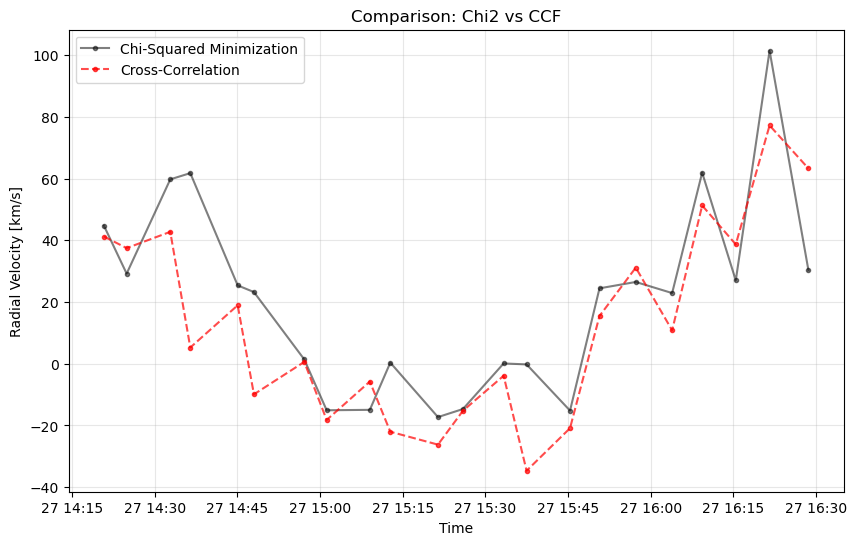

Mean offset between methods: 8.44 km/s
Scatter (std dev) between methods: 18.11 km/s


In [7]:
#Doing the actual cross-correlation 

rv_ccf_results = []
times_arr = ds.time.values

print("Starting Cross-Correlation...")

for i in range(len(times_arr)):
    f_obs = ds.flux_calibrated.values[i, :]
    w_obs = ds.wavelength.values #Assuming 1D shared wavelength

    
    try:
        rv = cross_correlate_rv(
            w_obs, f_obs, 
            model_wave_rest, model_flux_rest, 
            v_step=10.0 #10 km/s per pixel precision
        )
    except Exception as e:
        rv = np.nan
        
    rv_ccf_results.append(rv)

rv_ccf_results = np.array(rv_ccf_results)

#Plots the two methods (CC and CHI^2) side-by-side
plt.figure(figsize=(10, 6))

plt.plot(times_arr, rv_results, 'k.-', alpha=0.5, label='Chi-Squared Minimization')

plt.plot(times_arr, rv_ccf_results, 'r.--', alpha=0.7, label='Cross-Correlation')

plt.xlabel("Time")
plt.ylabel("Radial Velocity [km/s]")
plt.title("Comparison: Chi2 vs CCF")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Print Statistics
diff = rv_results - rv_ccf_results
print(f"Mean offset between methods: {np.nanmean(diff):.2f} km/s")
print(f"Scatter (std dev) between methods: {np.nanstd(diff):.2f} km/s")

### Plots the cross-correlation results by themselves ###

Fitting CCF results with guess: P=112.0, K=35.0

=== CCF FIT RESULTS ===
Period: 130.00 ± 17.57 min
Amplitude (K): 37.99 ± 5.05 km/s
System Velocity: 11.35 ± 5.84 km/s


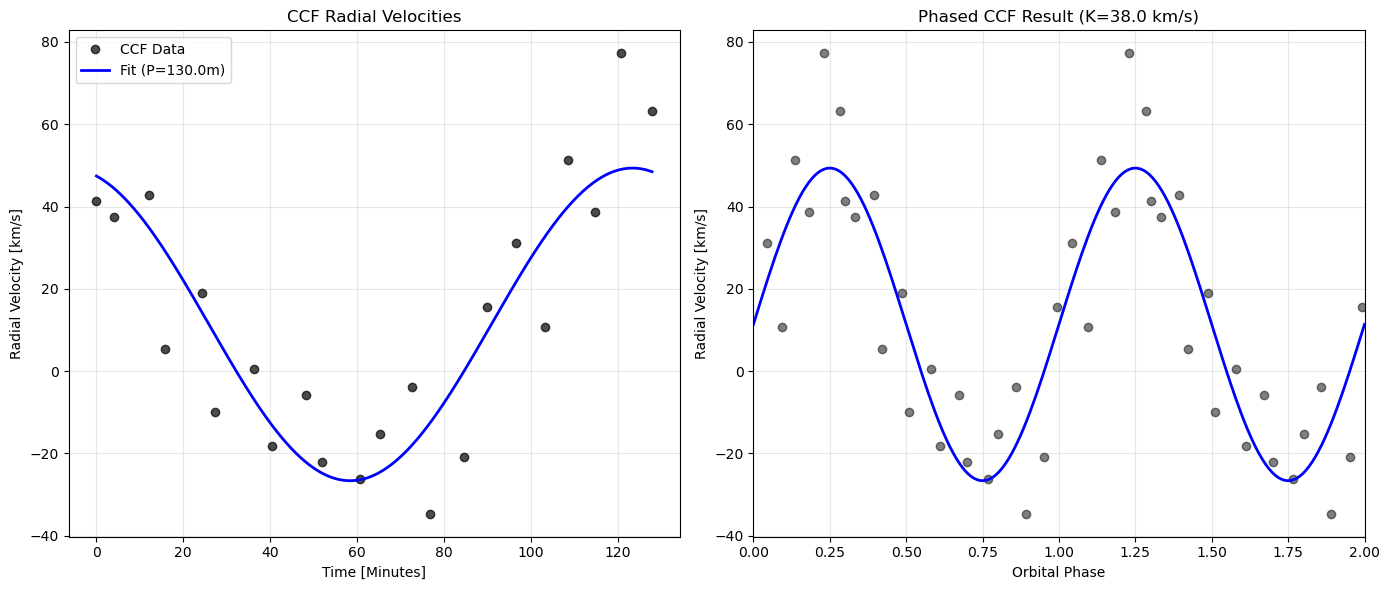

In [ ]:
#Use the results from the CCF loop
rv_data_ccf = np.array(rv_ccf_results)
t_raw = ds.time.values

#Convert Time to Minutes (same logic as before)
if np.issubdtype(t_raw.dtype, np.datetime64):
    t_start = t_raw.min()
    t_minutes = (t_raw - t_start) / np.timedelta64(1, 'm')
else:
    t_minutes = (t_raw - t_raw[0])

#Mask NaNs
mask = np.isfinite(rv_data_ccf)
t_fit = t_minutes[mask]
rv_fit = rv_data_ccf[mask]


def sine_model(t, gamma, K, P, T0):
 
    omega = 2 * np.pi / P
    return gamma + K * np.sin(omega * (t - T0))

#Priors (112 min, 35 km/s)
prior_P = 112.0
prior_K = 35.0
prior_gamma = np.mean(rv_fit)
prior_T0 = t_fit[0]

p0 = [prior_gamma, prior_K, prior_P, prior_T0]

#Bounds: period between 100 and 130 minutes, K positive
bounds = (
    [-np.inf, 0.0, 100.0, -np.inf], 
    [np.inf, 200.0, 130.0, np.inf]
)

print(f"Fitting CCF results with guess: P={prior_P}, K={prior_K}")

try:
    #no passing 'sigma' here because we don't have CCF errors calculated
        #assume equal weight for all points
    popt, pcov = curve_fit(
        sine_model, t_fit, rv_fit, p0=p0, bounds=bounds, maxfev=5000
    )
    
    gamma_best, K_best, P_best, T0_best = popt
    
    #Estimate parameter errors from covariance matrix
        #(scaled by the scatter of residuals since no given sigma)
    perr = np.sqrt(np.diag(pcov))

    print("\n=== CCF FIT RESULTS ===")
    print(f"Period: {P_best:.2f} ± {perr[2]:.2f} min")
    print(f"Amplitude (K): {K_best:.2f} ± {perr[1]:.2f} km/s")
    print(f"System Velocity: {gamma_best:.2f} ± {perr[0]:.2f} km/s")

except Exception as e:
    print("Fit failed:", e)
    popt = None


if popt is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    t_smooth = np.linspace(t_fit.min(), t_fit.max(), 1000)
    rv_model = sine_model(t_smooth, *popt)

    #Plot data
    ax1.plot(t_fit, rv_fit, 'ko', alpha=0.7, label='CCF Data')
    #Plot fit
    ax1.plot(t_smooth, rv_model, 'b-', lw=2, label=f'Fit (P={P_best:.1f}m)')
    
    ax1.set_xlabel("Time [Minutes]")
    ax1.set_ylabel("Radial Velocity [km/s]")
    ax1.set_title("CCF Radial Velocities")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    phase = ((t_fit - T0_best) % P_best) / P_best
    
    #Concatenate for 2 cycles
        #this helps us better visualize what the motion looks like across 2 periods
    phase_plot = np.concatenate([phase, phase + 1.0])
    rv_plot = np.concatenate([rv_fit, rv_fit])
    
    #Model grid
    p_smooth = np.linspace(0, 2, 200)
    m_smooth = gamma_best + K_best * np.sin(2 * np.pi * p_smooth)

    ax2.plot(phase_plot, rv_plot, 'ko', alpha=0.5)
    ax2.plot(p_smooth, m_smooth, 'b-', lw=2)
    
    ax2.set_xlabel("Orbital Phase")
    ax2.set_ylabel("Radial Velocity [km/s]")
    ax2.set_title(f"Phased CCF Result (K={K_best:.1f} km/s)")
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 2)

    plt.tight_layout()
    plt.show()

### This plots the cross-correlation results using monte carlo sampling for an extra error band ###

This is similar to the way we plotted the sinusoid during individual line fitting

<>:63: SyntaxWarning: invalid escape sequence '\s'
<>:77: SyntaxWarning: invalid escape sequence '\p'
<>:78: SyntaxWarning: invalid escape sequence '\p'
<>:79: SyntaxWarning: invalid escape sequence '\p'
<>:80: SyntaxWarning: invalid escape sequence '\p'
<>:63: SyntaxWarning: invalid escape sequence '\s'
<>:77: SyntaxWarning: invalid escape sequence '\p'
<>:78: SyntaxWarning: invalid escape sequence '\p'
<>:79: SyntaxWarning: invalid escape sequence '\p'
<>:80: SyntaxWarning: invalid escape sequence '\p'
C:\Users\ecpav\AppData\Local\Temp\ipykernel_24148\492739794.py:63: SyntaxWarning: invalid escape sequence '\s'
  color='blue', alpha=0.2, label='1$\sigma$ Confidence Band')
C:\Users\ecpav\AppData\Local\Temp\ipykernel_24148\492739794.py:77: SyntaxWarning: invalid escape sequence '\p'
  f"Amplitude = {K_fit:.2f} $\pm$ {perr[1]:.2f} km/s\n"
C:\Users\ecpav\AppData\Local\Temp\ipykernel_24148\492739794.py:78: SyntaxWarning: invalid escape sequence '\p'
  f"Period = {P_fit:.2f} $\pm$ {perr[2]

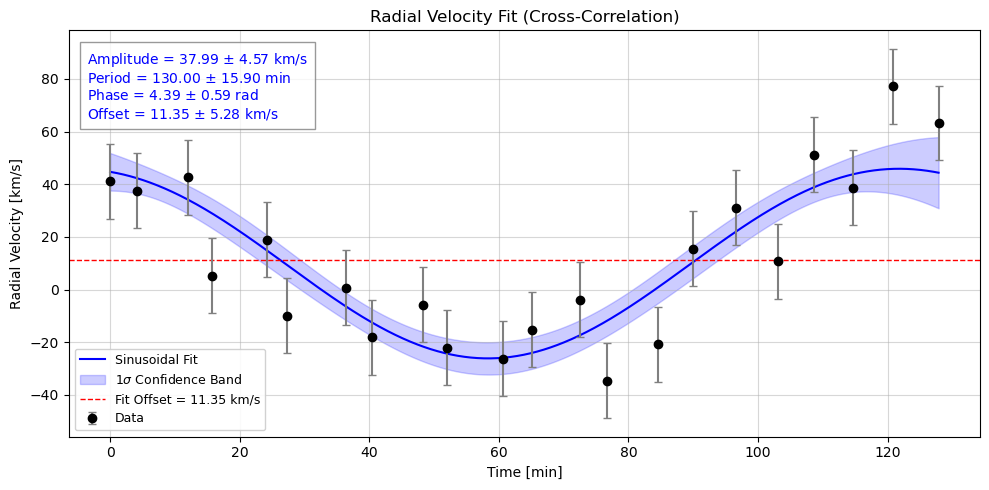

In [ ]:
rv_data = np.array(rv_ccf_results)
t_raw = ds.time.values

#Convert to Minutes
if np.issubdtype(t_raw.dtype, np.datetime64):
    t_start = t_raw.min()
    t_minutes = (t_raw - t_start) / np.timedelta64(1, 'm')
else:
    t_minutes = (t_raw - t_raw[0])

mask = np.isfinite(rv_data)
t_fit = t_minutes[mask]
rv_fit = rv_data[mask]


def sine_model(t, gamma, K, P, T0):
    omega = 2 * np.pi / P
    return gamma + K * np.sin(omega * (t - T0))

#Initial Guesses
p0 = [np.mean(rv_fit), 35.0, 112.0, t_fit[0]]
bounds = ([-np.inf, 0.0, 100.0, -np.inf], [np.inf, 200.0, 130.0, np.inf])

popt, pcov = curve_fit(sine_model, t_fit, rv_fit, p0=p0, bounds=bounds)

#Estimate error (Scatter/RMS of residuals)
residuals_raw = rv_fit - sine_model(t_fit, *popt)
sigma_res = np.std(residuals_raw)
errors = np.full_like(rv_fit, sigma_res) 

#Weighted fit to get parameter uncertainties (second pass)
popt, pcov = curve_fit(sine_model, t_fit, rv_fit, p0=p0, bounds=bounds, 
                       sigma=errors, absolute_sigma=True)

gamma_fit, K_fit, P_fit, T0_fit = popt
perr = np.sqrt(np.diag(pcov))

#MC confidence band
samples = 500
random_params = np.random.multivariate_normal(popt, pcov, samples)

t_smooth = np.linspace(t_fit.min(), t_fit.max(), 1000)
sample_curves = []

for param in random_params:
    sample_curves.append(sine_model(t_smooth, *param))

sample_curves = np.array(sample_curves)
model_mean = np.mean(sample_curves, axis=0)
model_std = np.std(sample_curves, axis=0)

#plotting
plt.figure(figsize=(10, 5))


#sinusoid
plt.plot(t_smooth, model_mean, 'b-', lw=1.5, label='Sinusoidal Fit')

#mc error band
plt.fill_between(t_smooth, model_mean - model_std, model_mean + model_std, 
                 color='blue', alpha=0.2, label='1$\sigma$ Confidence Band')

plt.axhline(gamma_fit, color='red', linestyle='--', lw=1, 
            label=f'Fit Offset = {gamma_fit:.2f} km/s')

#data
plt.errorbar(t_fit, rv_fit, yerr=sigma_res, fmt='ko', 
             ecolor='gray', elinewidth=1.5, capsize=3, label='Data')

#legend/displays the fit parameters
phase_rad = (T0_fit / P_fit) * 2 * np.pi
phase_err = (perr[3] / P_fit) * 2 * np.pi 

text_str = (
    f"Amplitude = {K_fit:.2f} $\pm$ {perr[1]:.2f} km/s\n"
    f"Period = {P_fit:.2f} $\pm$ {perr[2]:.2f} min\n"
    f"Phase = {phase_rad % (2*np.pi):.2f} $\pm$ {phase_err:.2f} rad\n"
    f"Offset = {gamma_fit:.2f} $\pm$ {perr[0]:.2f} km/s"
)

plt.gca().text(0.02, 0.95, text_str, transform=plt.gca().transAxes, fontsize=10,
               verticalalignment='top', color='blue',
               bbox=dict(boxstyle='square,pad=0.5', fc='white', ec='gray', alpha=0.8))

plt.xlabel("Time [min]")
plt.ylabel("Radial Velocity [km/s]")
plt.title("Radial Velocity Fit (Cross-Correlation)")
plt.legend(loc='lower left', fontsize=9, framealpha=0.9)
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()